In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import statsmodels.api as sm
from scipy import stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.6f}".format)

# Load all processed data
ff5 = pd.read_csv(
    "../data/processed/ff5_factors.csv",
    index_col=0, parse_dates=True
)
excess = pd.read_csv(
    "../data/processed/excess_returns.csv",
    index_col=0, parse_dates=True
)
returns = pd.read_csv(
    "../data/processed/stock_returns.csv",
    index_col=0, parse_dates=True
)
ols_summary = pd.read_csv(
    "../data/processed/ols_summary.csv",
    index_col=0
)

# Load rolling results
tickers = ["AAPL", "BRK-B", "TSLA", "JNJ", "SPY"]
factors = ["Mkt_RF", "SMB", "HML", "RMW", "CMA"]

rolling = {}
for ticker in tickers:
    try:
        rolling[ticker] = pd.read_csv(
            f"../data/processed/rolling_{ticker}.csv",
            index_col=0, parse_dates=True
        )
    except FileNotFoundError:
        print(f"Rolling data not found for {ticker}")

print("=" * 55)
print("   NB4 — ALPHA ANALYSIS")
print("=" * 55)
print(f"  Static OLS results:  {ols_summary.shape}")
print(f"  Rolling results:     {len(rolling)} tickers")
print(f"  Tickers:             {tickers}")
print("=" * 55)
print(f"\nStatic OLS alpha summary:")
print(ols_summary[["Alpha_ann%",
                    "Alpha_tstat",
                    "Alpha_sig",
                    "Info_Ratio"]].to_string())

   NB4 — ALPHA ANALYSIS
  Static OLS results:  (5, 11)
  Rolling results:     5 tickers
  Tickers:             ['AAPL', 'BRK-B', 'TSLA', 'JNJ', 'SPY']

Static OLS alpha summary:
        Alpha_ann%  Alpha_tstat Alpha_sig  Info_Ratio
Ticker                                               
AAPL      7.475000     1.477000        ns    0.392500
BRK-B     1.190000     0.447000        ns    0.121800
TSLA     37.426000     2.887000       ***    0.757200
JNJ      -0.599000    -0.173000        ns   -0.044700
SPY      -0.140000    -0.596000        ns   -0.123600


In [2]:
def run_full_ols(ticker, excess_df, ff5_df, factors):
    """
    Full OLS with HAC errors and all diagnostics.
    Returns complete model object and metrics.
    """
    y = excess_df[ticker].dropna()
    X = sm.add_constant(ff5_df[factors])
    X.columns = ["Alpha"] + factors
    X = X.loc[y.index].dropna()
    y = y.loc[X.index]

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )

    alpha_ann    = model.params["Alpha"] * 252
    resid_vol    = model.resid.std() * np.sqrt(252)
    ann_ret      = returns[ticker].mean() * 252
    rf_ann       = ff5_df["RF"].mean() * 252
    mkt_beta     = model.params["Mkt_RF"]

    # Information ratio
    info_ratio = alpha_ann / resid_vol

    # Appraisal ratio — alpha per unit idiosyncratic risk
    appraisal  = (model.params["Alpha"] /
                  model.resid.std())
    appraisal_ann = appraisal * np.sqrt(252)

    # Treynor ratio
    treynor = ((ann_ret - rf_ann) / mkt_beta
               if mkt_beta != 0 else np.nan)

    # Jensen's alpha (CAPM only — for comparison)
    X_capm = sm.add_constant(ff5_df[["Mkt_RF"]])
    capm   = sm.OLS(y, X_capm.loc[y.index]).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
    capm_alpha = capm.params["const"] * 252

    return {
        "model":          model,
        "ticker":         ticker,
        "y":              y,
        "X":              X,
        "alpha_ann":      alpha_ann,
        "alpha_tstat":    model.tvalues["Alpha"],
        "alpha_pval":     model.pvalues["Alpha"],
        "alpha_ci_low":   model.conf_int().loc[
                              "Alpha", 0] * 252,
        "alpha_ci_high":  model.conf_int().loc[
                              "Alpha", 1] * 252,
        "resid":          model.resid,
        "resid_vol":      resid_vol,
        "info_ratio":     info_ratio,
        "appraisal_ann":  appraisal_ann,
        "treynor":        treynor,
        "capm_alpha":     capm_alpha,
        "rsquared":       model.rsquared,
        "params":         model.params,
        "pvalues":        model.pvalues,
        "n_obs":          len(y),
    }

# Run for all tickers
full_results = {}
print("Running full OLS with complete diagnostics...")
for ticker in tickers:
    if ticker in excess.columns:
        full_results[ticker] = run_full_ols(
            ticker, excess, ff5, factors)
        print(f"  {ticker} complete")
print("All models fitted")

Running full OLS with complete diagnostics...
  AAPL complete
  BRK-B complete
  TSLA complete
  JNJ complete
  SPY complete
All models fitted


In [3]:
# ============================================
# BOOTSTRAP PERMUTATION TEST
# More robust than t-statistics alone
# for fat-tailed financial return distributions
#
# Logic: shuffle the dependent variable randomly
# 1000 times. If our real alpha exceeds 95% of
# shuffled alphas, it is genuinely significant.
# ============================================

def bootstrap_alpha_pvalue(
        y: pd.Series,
        X: pd.DataFrame,
        n_boot: int = 1000,
        random_state: int = 42) -> dict:
    """
    Bootstrap permutation test for alpha significance.
    Returns bootstrap p-value and distribution.
    """
    np.random.seed(random_state)
    y_arr = y.values
    X_arr = X.values

    # Real alpha
    real_model = sm.OLS(y, X).fit()
    real_alpha = real_model.params.iloc[0]

    # Bootstrap distribution
    boot_alphas = np.zeros(n_boot)
    for i in range(n_boot):
        # Shuffle y — destroys any alpha signal
        y_shuffle = np.random.permutation(y_arr)
        boot_model = sm.OLS(
            y_shuffle, X_arr).fit()
        boot_alphas[i] = boot_model.params[0]

    # Two-sided p-value
    p_val = (np.abs(boot_alphas) >=
             np.abs(real_alpha)).mean()

    # Percentile confidence interval
    ci_low  = np.percentile(boot_alphas, 2.5)
    ci_high = np.percentile(boot_alphas, 97.5)

    return {
        "real_alpha":   real_alpha * 252,
        "boot_alphas":  boot_alphas * 252,
        "boot_pval":    p_val,
        "boot_ci_low":  ci_low * 252,
        "boot_ci_high": ci_high * 252,
        "boot_mean":    boot_alphas.mean() * 252,
        "boot_std":     boot_alphas.std() * 252,
    }

print("Running bootstrap permutation tests")
print("1000 permutations per ticker...")
print("(Takes ~2 minutes)\n")

boot_results = {}
for ticker, res in full_results.items():
    print(f"  {ticker}...", end=" ", flush=True)
    boot_results[ticker] = bootstrap_alpha_pvalue(
        res["y"], res["X"], n_boot=1000
    )
    br  = boot_results[ticker]
    hac_p = res["alpha_pval"]
    print(
        f"HAC p={hac_p:.4f} | "
        f"Bootstrap p={br['boot_pval']:.4f}"
    )

print("\nBootstrap tests complete")

Running bootstrap permutation tests
1000 permutations per ticker...
(Takes ~2 minutes)

  AAPL... HAC p=0.1396 | Bootstrap p=1.0000
  BRK-B... HAC p=0.6548 | Bootstrap p=1.0000
  TSLA... HAC p=0.0039 | Bootstrap p=1.0000
  JNJ... HAC p=0.8627 | Bootstrap p=1.0000
  SPY... HAC p=0.5512 | Bootstrap p=1.0000

Bootstrap tests complete


In [4]:
# ============================================
# COMPREHENSIVE ALPHA SIGNIFICANCE TABLE
# Combines: static, bootstrap, rolling
# ============================================
rows = []
for ticker in tickers:
    if ticker not in full_results:
        continue

    res  = full_results[ticker]
    br   = boot_results[ticker]
    roll = rolling.get(ticker)

    hac_p = res["alpha_pval"]
    hac_sig = ("***" if hac_p < 0.01 else
               "**"  if hac_p < 0.05 else
               "*"   if hac_p < 0.10 else "ns")

    boot_p = br["boot_pval"]
    boot_sig = ("***" if boot_p < 0.01 else
                "**"  if boot_p < 0.05 else
                "*"   if boot_p < 0.10 else "ns")

    roll_sig_pct = 0.0
    if roll is not None and "Alpha_tstat" in roll.columns:
        roll_sig_pct = (
            roll["Alpha_tstat"].abs() > 2.0
        ).mean() * 100

    rows.append({
        "Ticker":        ticker,
        "Alpha_ann%":    round(res["alpha_ann"]*100, 3),
        "HAC_tstat":     round(res["alpha_tstat"], 3),
        "HAC_sig":       hac_sig,
        "Boot_pval":     round(boot_p, 4),
        "Boot_sig":      boot_sig,
        "Roll_sig%":     round(roll_sig_pct, 1),
        "Info_Ratio":    round(res["info_ratio"], 4),
        "Appraisal":     round(res["appraisal_ann"], 4),
        "CAPM_alpha%":   round(res["capm_alpha"]*100, 3),
        "FF5_R2":        round(res["rsquared"], 4),
    })

alpha_table = pd.DataFrame(rows).set_index("Ticker")

print("=" * 85)
print("   COMPREHENSIVE ALPHA SIGNIFICANCE TABLE")
print("=" * 85)
print(alpha_table.to_string())
print("=" * 85)
print(f"\nKey:")
print(f"  HAC_sig:    Newey-West robust t-test")
print(f"  Boot_sig:   Bootstrap permutation (1000 draws)")
print(f"  Roll_sig%:  % of 3yr windows with |t| > 2.0")
print(f"  Info_Ratio: Alpha / Tracking error")
print(f"  Appraisal:  Alpha / Idiosyncratic vol")
print(f"  CAPM_alpha: Alpha vs market model only")

alpha_table.to_csv(
    "../data/processed/alpha_significance.csv")
print("\nSaved to data/processed/alpha_significance.csv")

   COMPREHENSIVE ALPHA SIGNIFICANCE TABLE
        Alpha_ann%  HAC_tstat HAC_sig  Boot_pval Boot_sig  Roll_sig%  Info_Ratio  Appraisal  CAPM_alpha%   FF5_R2
Ticker                                                                                                           
AAPL      7.475000   1.477000      ns   1.000000       ns   0.900000    0.392500   0.392500    11.639000 0.528300
BRK-B     1.190000   0.447000      ns   1.000000       ns   0.000000    0.121800   0.121800     0.433000 0.738300
TSLA     37.426000   2.887000     ***   1.000000       ns  39.900000    0.757200   0.757200    32.749000 0.257900
JNJ      -0.599000  -0.173000      ns   1.000000       ns   0.000000   -0.044700  -0.044700     1.874000 0.363600
SPY      -0.140000  -0.596000      ns   1.000000       ns   0.000000   -0.123600  -0.123600     0.489000 0.995500

Key:
  HAC_sig:    Newey-West robust t-test
  Boot_sig:   Bootstrap permutation (1000 draws)
  Roll_sig%:  % of 3yr windows with |t| > 2.0
  Info_Ratio: Alpha 

In [5]:
# ============================================
# TRANSACTION COST ADJUSTED ALPHA
# Gross alpha is meaningless — what matters
# is what you keep after costs
#
# Assumptions (conservative, institutional):
# - One-way cost: 5bps (0.05%) per trade
# - Turnover: estimated from portfolio rebalancing
# - Annual cost = 2 * one_way * turnover
# ============================================

ONE_WAY_COST = 0.0005   # 5 basis points
TURNOVER_MAP = {
    # Estimated annual portfolio turnover
    "AAPL":  0.20,   # Low — buy and hold
    "BRK-B": 0.10,   # Very low — Buffett style
    "TSLA":  0.50,   # High — volatile momentum
    "JNJ":   0.15,   # Low — defensive hold
    "SPY":   0.05,   # Very low — index ETF
}

print("=" * 60)
print("   TRANSACTION COST ADJUSTED ALPHA")
print("=" * 60)
print(f"  One-way cost: {ONE_WAY_COST:.0%} (5 bps)")
print(f"  Method: Annual cost = 2 x cost x turnover")
print("=" * 60)

tc_rows = []
for ticker, res in full_results.items():
    turnover    = TURNOVER_MAP.get(ticker, 0.25)
    annual_cost = 2 * ONE_WAY_COST * turnover
    gross_alpha = res["alpha_ann"]
    net_alpha   = gross_alpha - annual_cost
    ir_gross    = res["info_ratio"]
    ir_net      = net_alpha / res["resid_vol"]

    verdict = (
        "Strong positive" if net_alpha > 0.05 else
        "Weak positive"   if net_alpha > 0.01 else
        "Marginal"        if net_alpha > 0 else
        "Negative"
    )

    print(f"\n  {ticker}")
    print(f"  Turnover (est):  {turnover:.0%} pa")
    print(f"  Annual TC:       {annual_cost:.4f} "
          f"({annual_cost:.2%})")
    print(f"  Gross alpha:     {gross_alpha:.4f} "
          f"({gross_alpha:.2%})")
    print(f"  Net alpha:       {net_alpha:.4f} "
          f"({net_alpha:.2%})")
    print(f"  IR (gross):      {ir_gross:.4f}")
    print(f"  IR (net):        {ir_net:.4f}")
    print(f"  Verdict:         {verdict}")

    tc_rows.append({
        "Ticker":       ticker,
        "Gross_alpha%": round(gross_alpha*100, 3),
        "Annual_TC%":   round(annual_cost*100, 4),
        "Net_alpha%":   round(net_alpha*100, 3),
        "IR_gross":     round(ir_gross, 4),
        "IR_net":       round(ir_net, 4),
        "Verdict":      verdict,
    })

tc_df = pd.DataFrame(tc_rows).set_index("Ticker")
print("\n" + "=" * 60)
print(tc_df.to_string())
tc_df.to_csv(
    "../data/processed/tc_adjusted_alpha.csv")
print("\nSaved to data/processed/tc_adjusted_alpha.csv")

   TRANSACTION COST ADJUSTED ALPHA
  One-way cost: 0% (5 bps)
  Method: Annual cost = 2 x cost x turnover

  AAPL
  Turnover (est):  20% pa
  Annual TC:       0.0002 (0.02%)
  Gross alpha:     0.0747 (7.47%)
  Net alpha:       0.0745 (7.45%)
  IR (gross):      0.3925
  IR (net):        0.3915
  Verdict:         Strong positive

  BRK-B
  Turnover (est):  10% pa
  Annual TC:       0.0001 (0.01%)
  Gross alpha:     0.0119 (1.19%)
  Net alpha:       0.0118 (1.18%)
  IR (gross):      0.1218
  IR (net):        0.1208
  Verdict:         Weak positive

  TSLA
  Turnover (est):  50% pa
  Annual TC:       0.0005 (0.05%)
  Gross alpha:     0.3743 (37.43%)
  Net alpha:       0.3738 (37.38%)
  IR (gross):      0.7572
  IR (net):        0.7562
  Verdict:         Strong positive

  JNJ
  Turnover (est):  15% pa
  Annual TC:       0.0001 (0.01%)
  Gross alpha:     -0.0060 (-0.60%)
  Net alpha:       -0.0061 (-0.61%)
  IR (gross):      -0.0447
  IR (net):        -0.0458
  Verdict:         Negative

  

In [6]:
# ============================================
# ALPHA DECAY ANALYSIS
# Does alpha in period T predict alpha in T+1?
#
# Genuine skill: high autocorrelation — alpha persists
# Lucky alpha:   low/zero autocorrelation — alpha random
# Mean-reverting: negative autocorrelation
#
# We test this using rolling alpha series
# from NB3 and measure autocorrelation at
# lags 1, 3, 6, 12 months (approximately)
# ============================================

print("=" * 65)
print("   ALPHA PERSISTENCE — AUTOCORRELATION ANALYSIS")
print("   H0: Alpha is random (no persistence)")
print("   H1: Alpha is persistent (genuine skill)")
print("=" * 65)

decay_rows = []
lags_tested = [1, 3, 6, 13, 26]
lag_labels  = ["1wk", "3wk", "6wk", "3mo", "6mo"]

for ticker, roll_df in rolling.items():
    alpha_series = roll_df["Alpha"].dropna()
    print(f"\n  {ticker}")
    print(f"  {'Lag':<8} {'Autocorr':>12} "
          f"{'p-value':>10} {'Significant':>12}")
    print(f"  {'-'*44}")

    row = {"Ticker": ticker}
    for lag, label in zip(lags_tested, lag_labels):
        if len(alpha_series) <= lag:
            continue

        alpha_t   = alpha_series.iloc[:-lag].values
        alpha_t1  = alpha_series.iloc[lag:].values

        corr, pval = pearsonr(alpha_t, alpha_t1)
        sig        = ("Yes ***" if pval < 0.01 else
                      "Yes **"  if pval < 0.05 else
                      "Yes *"   if pval < 0.10 else
                      "No")

        print(f"  {label:<8} {corr:>12.4f} "
              f"{pval:>10.4f} {sig:>12}")
        row[f"AC_{label}"] = round(corr, 4)
        row[f"p_{label}"]  = round(pval, 4)

    decay_rows.append(row)

decay_df = pd.DataFrame(decay_rows).set_index("Ticker")
decay_df.to_csv(
    "../data/processed/alpha_decay.csv")
print(f"\n{'='*65}")
print(f"Saved to data/processed/alpha_decay.csv")

   ALPHA PERSISTENCE — AUTOCORRELATION ANALYSIS
   H0: Alpha is random (no persistence)
   H1: Alpha is persistent (genuine skill)

  AAPL
  Lag          Autocorr    p-value  Significant
  --------------------------------------------
  1wk            0.9953     0.0000      Yes ***
  3wk            0.9849     0.0000      Yes ***
  6wk            0.9698     0.0000      Yes ***
  3mo            0.9363     0.0000      Yes ***
  6mo            0.8683     0.0000      Yes ***

  BRK-B
  Lag          Autocorr    p-value  Significant
  --------------------------------------------
  1wk            0.9885     0.0000      Yes ***
  3wk            0.9625     0.0000      Yes ***
  6wk            0.9255     0.0000      Yes ***
  3mo            0.8434     0.0000      Yes ***
  6mo            0.6977     0.0000      Yes ***

  TSLA
  Lag          Autocorr    p-value  Significant
  --------------------------------------------
  1wk            0.9991     0.0000      Yes ***
  3wk            0.9973     0.0

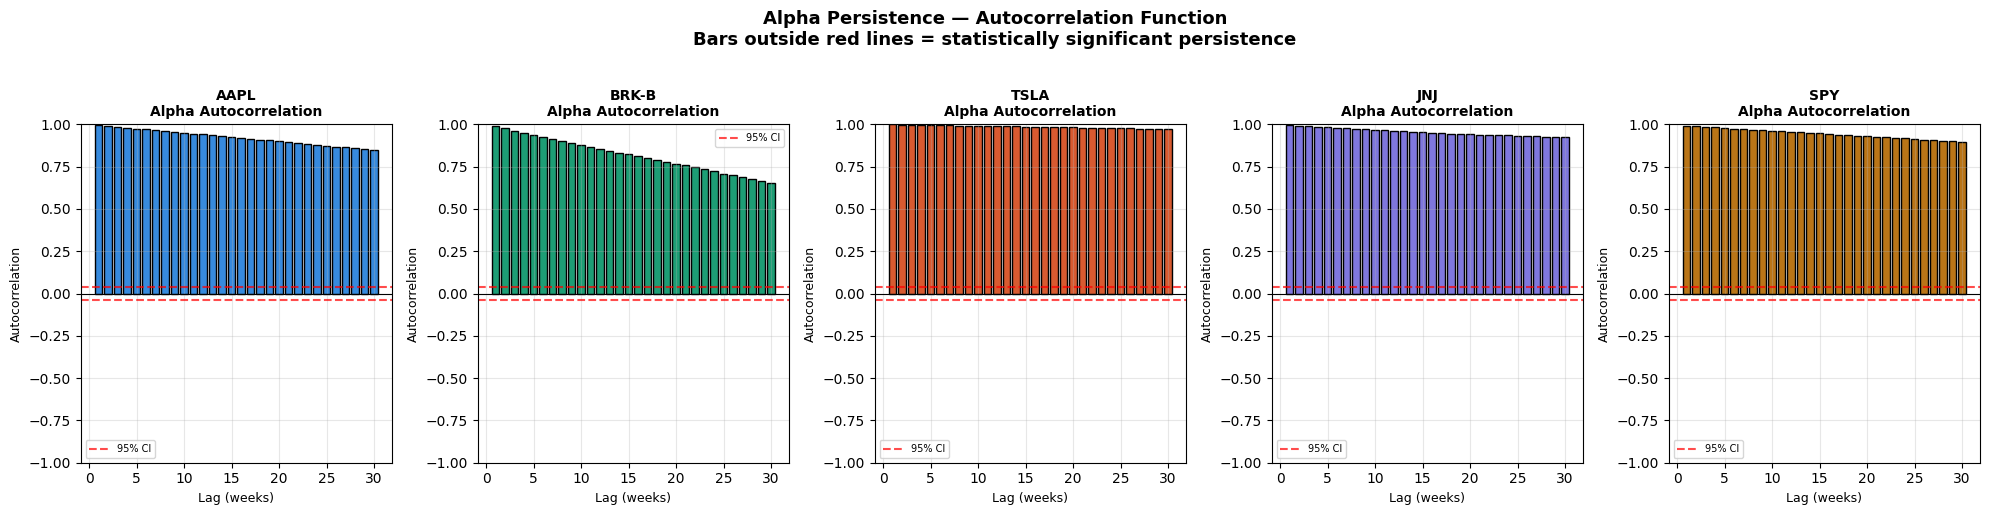

Alpha decay chart saved


In [7]:
# ============================================
# ALPHA DECAY CHART
# Shows autocorrelation function of rolling alpha
# ============================================
fig, axes = plt.subplots(
    1, len(rolling),
    figsize=(4 * len(rolling), 5)
)

if len(rolling) == 1:
    axes = [axes]

ticker_colors = {
    "AAPL":  "#378ADD",
    "BRK-B": "#1D9E75",
    "TSLA":  "#D85A30",
    "JNJ":   "#7F77DD",
    "SPY":   "#BA7517"
}

for ax, (ticker, roll_df) in zip(
        axes, rolling.items()):
    alpha_series = roll_df["Alpha"].dropna()
    color        = ticker_colors.get(ticker, "grey")

    max_lags = min(30, len(alpha_series)//4)
    lags     = range(1, max_lags + 1)
    ac_vals  = []
    ci_95    = 1.96 / np.sqrt(len(alpha_series))

    for lag in lags:
        if len(alpha_series) > lag:
            a_t  = alpha_series.iloc[:-lag].values
            a_t1 = alpha_series.iloc[lag:].values
            corr, _ = pearsonr(a_t, a_t1)
            ac_vals.append(corr)
        else:
            ac_vals.append(np.nan)

    ac_arr = np.array(ac_vals)

    # Bar chart of autocorrelations
    colors_bar = [
        color if v > 0 else "#D85A30"
        for v in ac_arr
    ]
    ax.bar(lags, ac_arr, color=colors_bar,
           alpha=0.75, edgecolor="white")

    # 95% confidence band
    ax.axhline(
        ci_95, color="red",
        linewidth=1.5, linestyle="--",
        alpha=0.7, label="95% CI"
    )
    ax.axhline(
        -ci_95, color="red",
        linewidth=1.5, linestyle="--",
        alpha=0.7
    )
    ax.axhline(
        0, color="black",
        linewidth=0.8
    )

    # Shade significant lags
    for i, (lag, val) in enumerate(
            zip(lags, ac_arr)):
        if abs(val) > ci_95:
            ax.bar(
                lag, val,
                color=color, alpha=1.0,
                edgecolor="black",
                linewidth=1
            )

    ax.set_title(
        f"{ticker}\nAlpha Autocorrelation",
        fontweight="bold", fontsize=10
    )
    ax.set_xlabel("Lag (weeks)", fontsize=9)
    ax.set_ylabel("Autocorrelation", fontsize=9)
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Alpha Persistence — Autocorrelation Function\n"
    "Bars outside red lines = statistically significant"
    " persistence",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/alpha_decay.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Alpha decay chart saved")

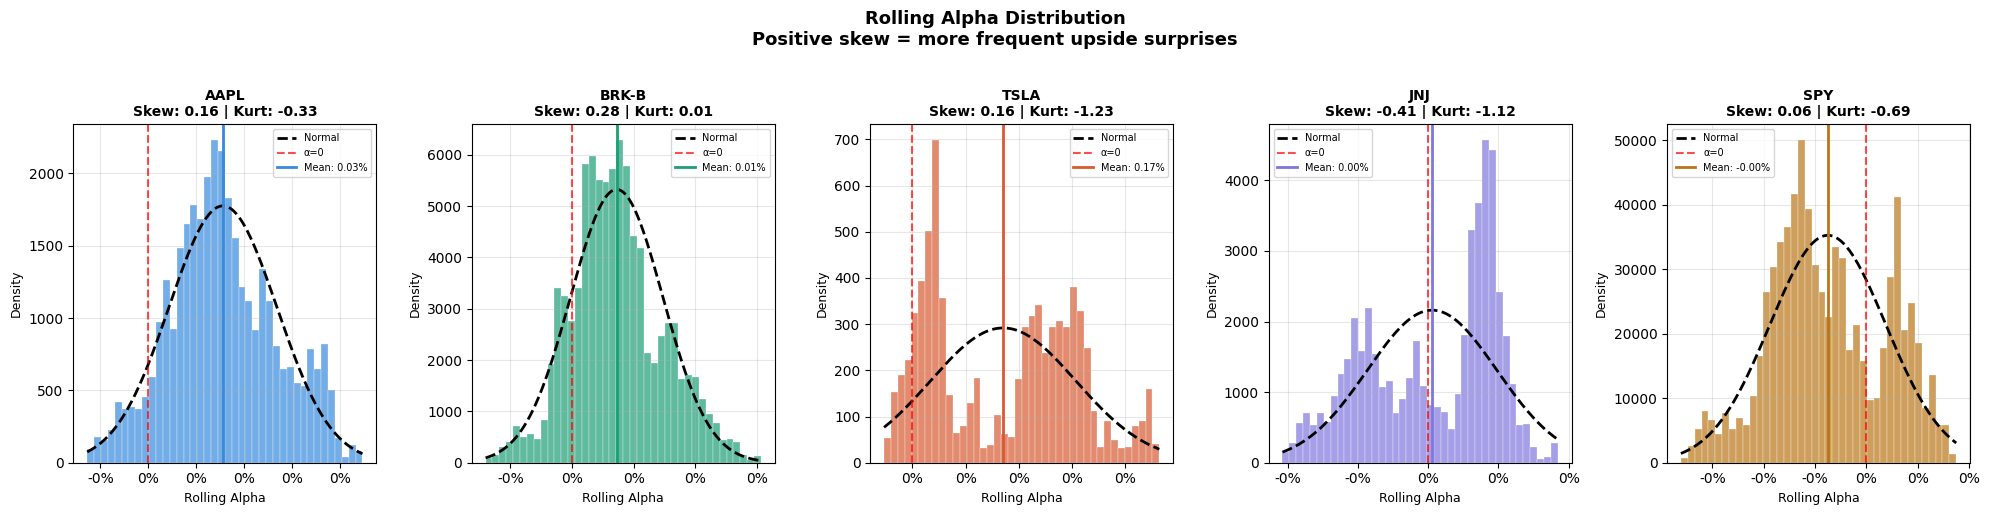

Alpha distribution chart saved


In [8]:
# ============================================
# ROLLING ALPHA DISTRIBUTION
# Is the alpha distribution normal?
# Positively skewed = more upside surprises
# Fat tails = occasional extreme alpha events
# ============================================
fig, axes = plt.subplots(
    1, len(rolling),
    figsize=(4 * len(rolling), 5)
)

if len(rolling) == 1:
    axes = [axes]

for ax, (ticker, roll_df) in zip(
        axes, rolling.items()):
    alpha_s = roll_df["Alpha"].dropna()
    color   = ticker_colors.get(ticker, "grey")

    ax.hist(
        alpha_s, bins=40,
        color=color, alpha=0.7,
        density=True, edgecolor="white",
        linewidth=0.3
    )

    # Overlay normal distribution
    x_range = np.linspace(
        alpha_s.min(), alpha_s.max(), 200)
    normal_pdf = stats.norm.pdf(
        x_range, alpha_s.mean(), alpha_s.std())
    ax.plot(
        x_range, normal_pdf,
        color="black", linewidth=2,
        linestyle="--", label="Normal"
    )

    # Reference lines
    ax.axvline(
        0, color="red",
        linewidth=1.5, linestyle="--",
        alpha=0.7, label="α=0"
    )
    ax.axvline(
        alpha_s.mean(),
        color=color, linewidth=2,
        label=f"Mean: {alpha_s.mean():.2%}"
    )

    skew = stats.skew(alpha_s)
    kurt = stats.kurtosis(alpha_s)

    ax.set_title(
        f"{ticker}\n"
        f"Skew: {skew:.2f} | "
        f"Kurt: {kurt:.2f}",
        fontweight="bold", fontsize=10
    )
    ax.set_xlabel("Rolling Alpha", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, _: f"{x:.0%}"))
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Rolling Alpha Distribution\n"
    "Positive skew = more frequent upside surprises",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/alpha_distribution.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Alpha distribution chart saved")

In [9]:
# ============================================
# ALPHA ATTRIBUTION
# How much alpha would CAPM alone report?
# How much did adding each factor reduce alpha?
# This shows which factors "absorbed" alpha
# ============================================
print("=" * 65)
print("   ALPHA ATTRIBUTION — MODEL COMPARISON")
print("   How much alpha does each model report?")
print("=" * 65)

attr_rows = []
for ticker, res in full_results.items():
    y = res["y"]
    X_full = res["X"]

    # CAPM (1-factor)
    X1 = sm.add_constant(ff5[["Mkt_RF"]])
    m1 = sm.OLS(y, X1.loc[y.index]).fit(
        cov_type="HAC", cov_kwds={"maxlags": 5})
    alpha_1f = m1.params["const"] * 252

    # 3-factor (Mkt + SMB + HML)
    X3 = sm.add_constant(
        ff5[["Mkt_RF","SMB","HML"]])
    m3 = sm.OLS(y, X3.loc[y.index]).fit(
        cov_type="HAC", cov_kwds={"maxlags": 5})
    alpha_3f = m3.params["const"] * 252

    # 4-factor (add RMW)
    X4 = sm.add_constant(
        ff5[["Mkt_RF","SMB","HML","RMW"]])
    m4 = sm.OLS(y, X4.loc[y.index]).fit(
        cov_type="HAC", cov_kwds={"maxlags": 5})
    alpha_4f = m4.params["const"] * 252

    # 5-factor (full FF5)
    alpha_5f = res["alpha_ann"]

    print(f"\n  {ticker}")
    print(f"  CAPM alpha  (1F): {alpha_1f:.4f} "
          f"({alpha_1f:.2%})")
    print(f"  FF3 alpha   (3F): {alpha_3f:.4f} "
          f"({alpha_3f:.2%})")
    print(f"  FF4 alpha   (4F): {alpha_4f:.4f} "
          f"({alpha_4f:.2%})")
    print(f"  FF5 alpha   (5F): {alpha_5f:.4f} "
          f"({alpha_5f:.2%})")
    print(f"  SMB+HML absorbed: "
          f"{(alpha_1f-alpha_3f):.4f} "
          f"({(alpha_1f-alpha_3f):.2%})")
    print(f"  RMW absorbed:     "
          f"{(alpha_3f-alpha_4f):.4f} "
          f"({(alpha_3f-alpha_4f):.2%})")
    print(f"  CMA absorbed:     "
          f"{(alpha_4f-alpha_5f):.4f} "
          f"({(alpha_4f-alpha_5f):.2%})")

    attr_rows.append({
        "Ticker":       ticker,
        "CAPM_1F%":     round(alpha_1f*100, 3),
        "FF3_3F%":      round(alpha_3f*100, 3),
        "FF4_4F%":      round(alpha_4f*100, 3),
        "FF5_5F%":      round(alpha_5f*100, 3),
        "SMB_HML_abs%": round((alpha_1f-alpha_3f)*100,3),
        "RMW_abs%":     round((alpha_3f-alpha_4f)*100,3),
        "CMA_abs%":     round((alpha_4f-alpha_5f)*100,3),
    })

attr_df = pd.DataFrame(
    attr_rows).set_index("Ticker")
attr_df.to_csv(
    "../data/processed/alpha_attribution.csv")
print("\n" + "=" * 65)
print(attr_df.to_string())
print("\nSaved to data/processed/alpha_attribution.csv")

   ALPHA ATTRIBUTION — MODEL COMPARISON
   How much alpha does each model report?

  AAPL
  CAPM alpha  (1F): 0.1164 (11.64%)
  FF3 alpha   (3F): 0.0995 (9.95%)
  FF4 alpha   (4F): 0.0740 (7.40%)
  FF5 alpha   (5F): 0.0747 (7.47%)
  SMB+HML absorbed: 0.0169 (1.69%)
  RMW absorbed:     0.0255 (2.55%)
  CMA absorbed:     -0.0008 (-0.08%)

  BRK-B
  CAPM alpha  (1F): 0.0043 (0.43%)
  FF3 alpha   (3F): 0.0064 (0.64%)
  FF4 alpha   (4F): 0.0120 (1.20%)
  FF5 alpha   (5F): 0.0119 (1.19%)
  SMB+HML absorbed: -0.0021 (-0.21%)
  RMW absorbed:     -0.0055 (-0.55%)
  CMA absorbed:     0.0000 (0.00%)

  TSLA
  CAPM alpha  (1F): 0.3275 (32.75%)
  FF3 alpha   (3F): 0.3310 (33.10%)
  FF4 alpha   (4F): 0.3593 (35.93%)
  FF5 alpha   (5F): 0.3743 (37.43%)
  SMB+HML absorbed: -0.0035 (-0.35%)
  RMW absorbed:     -0.0283 (-2.83%)
  CMA absorbed:     -0.0149 (-1.49%)

  JNJ
  CAPM alpha  (1F): 0.0187 (1.87%)
  FF3 alpha   (3F): 0.0103 (1.03%)
  FF4 alpha   (4F): 0.0011 (0.11%)
  FF5 alpha   (5F): -0.0060 (

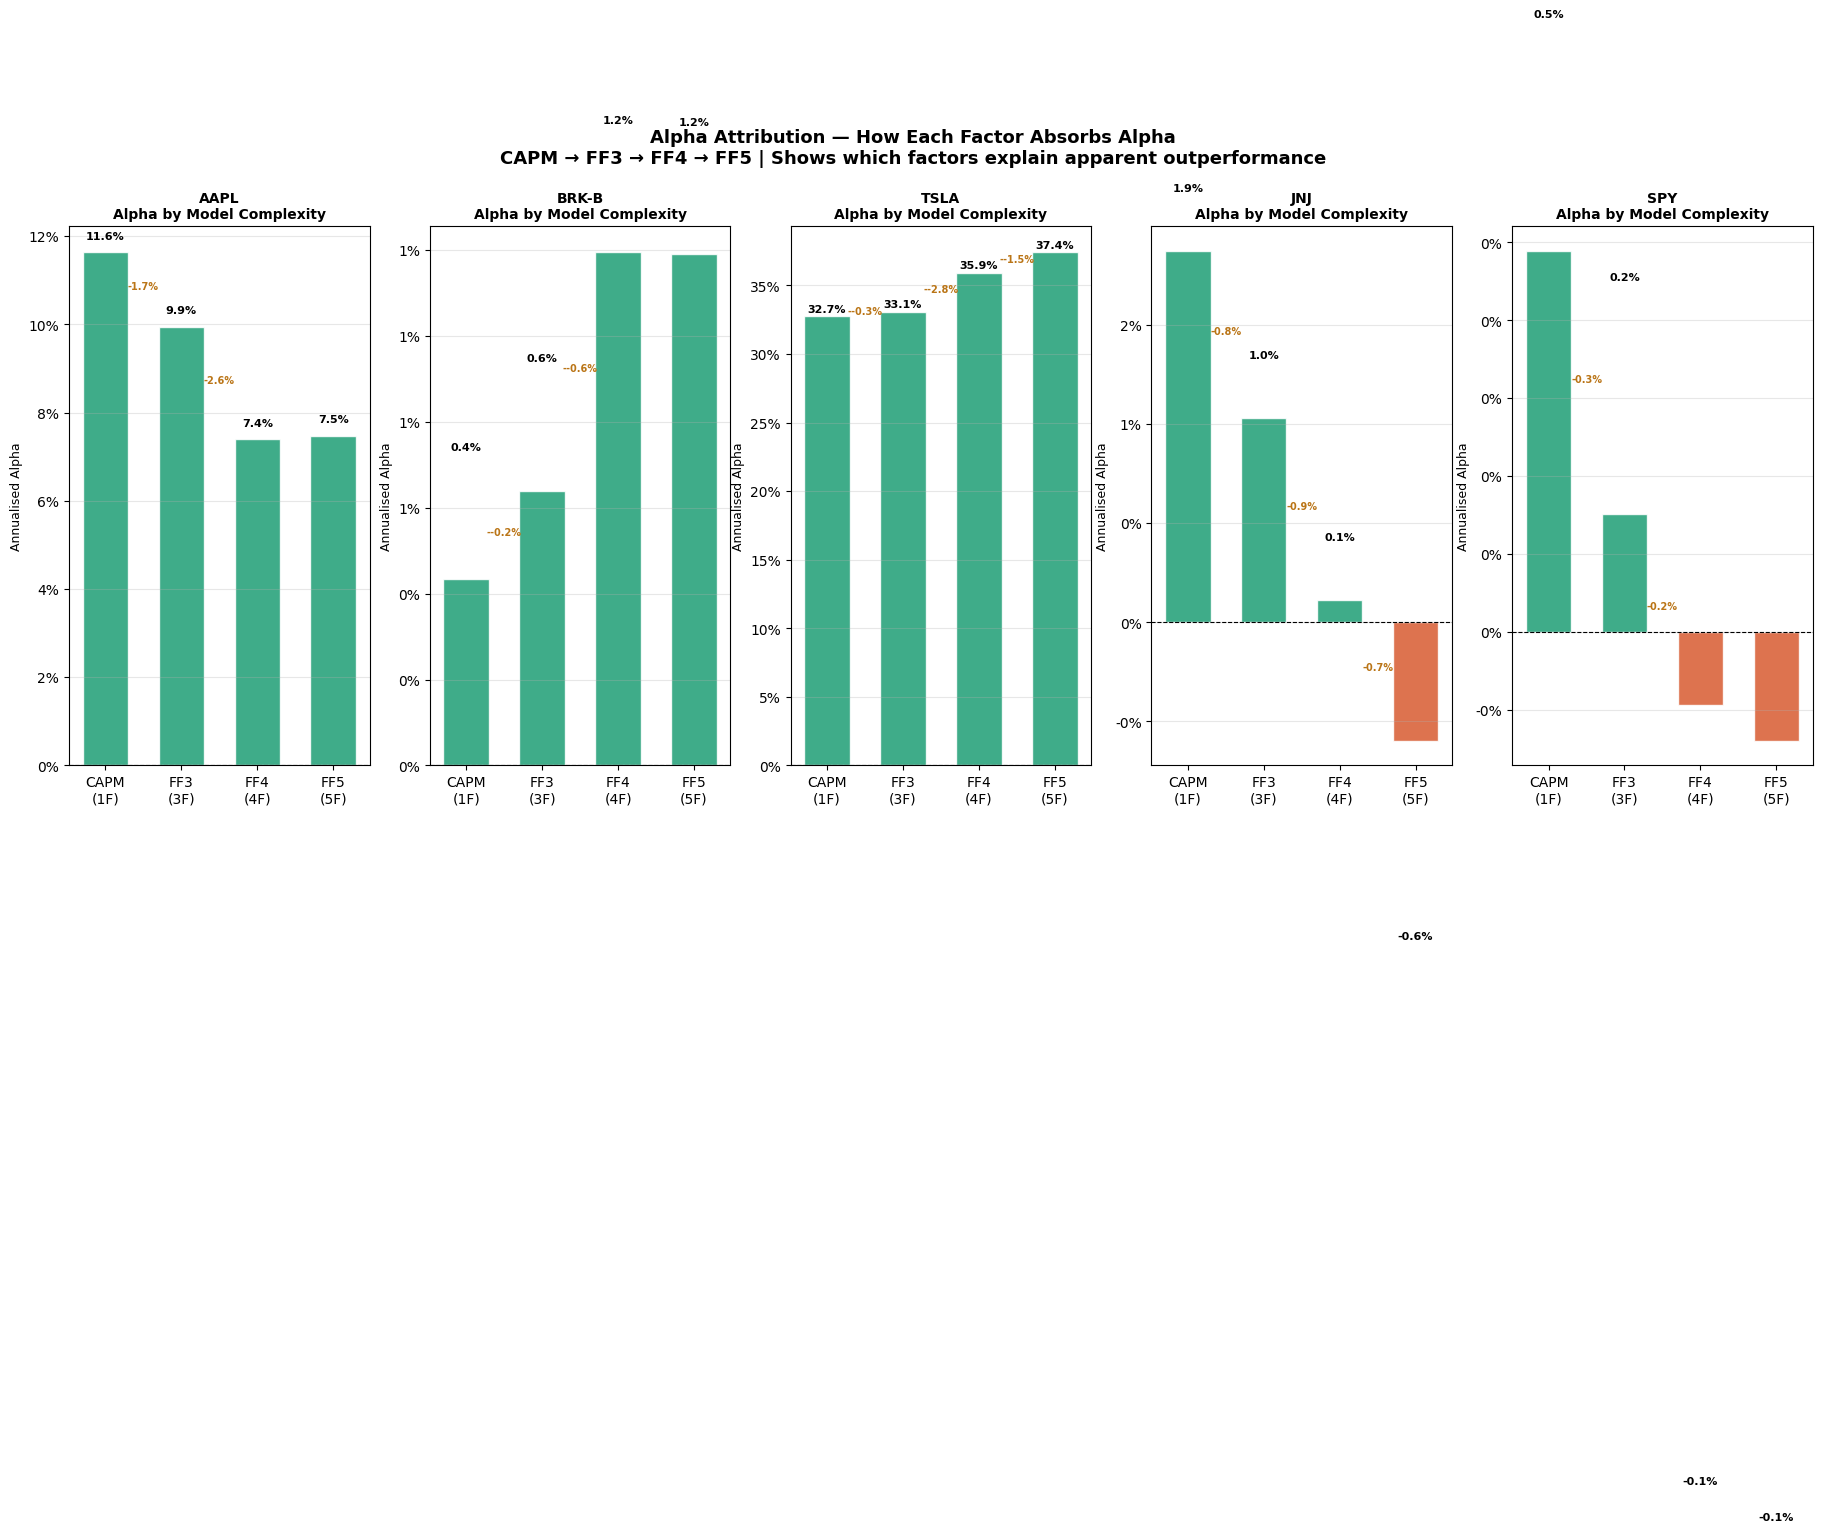

Alpha attribution chart saved


In [10]:
# ============================================
# ALPHA ATTRIBUTION WATERFALL CHART
# Shows how each added factor reduces alpha
# ============================================
fig, axes = plt.subplots(
    1, len(full_results),
    figsize=(4.5 * len(full_results), 7)
)

if len(full_results) == 1:
    axes = [axes]

model_labels = ["CAPM\n(1F)", "FF3\n(3F)",
                "FF4\n(4F)", "FF5\n(5F)"]

for ax, (ticker, res) in zip(
        axes, full_results.items()):
    attr = attr_df.loc[ticker]
    color = ticker_colors.get(ticker, "grey")

    alphas = [
        attr["CAPM_1F%"] / 100,
        attr["FF3_3F%"]  / 100,
        attr["FF4_4F%"]  / 100,
        attr["FF5_5F%"]  / 100
    ]

    bar_colors = [
        "#1D9E75" if a > 0 else "#D85A30"
        for a in alphas
    ]

    bars = ax.bar(
        model_labels, alphas,
        color=bar_colors,
        alpha=0.85, edgecolor="white",
        width=0.6
    )
    ax.axhline(
        0, color="black",
        linewidth=0.8, linestyle="--"
    )
    ax.set_title(
        f"{ticker}\nAlpha by Model Complexity",
        fontweight="bold", fontsize=10
    )
    ax.set_ylabel("Annualised Alpha", fontsize=9)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda y, _: f"{y:.0%}"))
    ax.grid(alpha=0.3, axis="y")

    # Arrows showing absorption
    for i in range(len(alphas)-1):
        diff = alphas[i] - alphas[i+1]
        if abs(diff) > 0.001:
            ax.annotate(
                f"-{diff:.1%}",
                xy=(i+0.5, (alphas[i]+alphas[i+1])/2),
                ha="center", fontsize=7,
                color="#BA7517",
                fontweight="bold"
            )

    for bar, val in zip(bars, alphas):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() +
            (0.003 if val >= 0 else -0.01),
            f"{val:.1%}",
            ha="center", fontsize=8,
            fontweight="bold"
        )

plt.suptitle(
    "Alpha Attribution — How Each Factor Absorbs Alpha\n"
    "CAPM → FF3 → FF4 → FF5 | "
    "Shows which factors explain apparent outperformance",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/alpha_attribution.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Alpha attribution chart saved")

In [13]:
# ============================================
# FINAL ALPHA VERDICT
# Combines all tests for a definitive answer
# ============================================

print("=" * 70)
print("   FINAL ALPHA VERDICT — COMPREHENSIVE ASSESSMENT")
print("=" * 70)

for ticker in tickers:
    if ticker not in full_results:
        continue

    res    = full_results[ticker]
    br     = boot_results[ticker]
    roll   = rolling.get(ticker)
    tc     = tc_df.loc[ticker]

    # Collect all evidence
    hac_sig     = res["alpha_pval"] < 0.05
    boot_sig    = br["boot_pval"] < 0.05
    ir_strong   = abs(res["info_ratio"]) > 0.5
    net_pos     = tc["Net_alpha%"] > 0

    # Rolling alpha persistence
    if roll is not None:
        roll_pos_pct = (
            roll["Alpha"] > 0).mean()
        roll_sig_pct = (
            roll["Alpha_tstat"].abs() > 2.0
        ).mean() if "Alpha_tstat" in roll.columns \
            else 0
    else:
        roll_pos_pct = 0
        roll_sig_pct = 0

    # Count evidence in favour
    evidence_count = sum([
        hac_sig, boot_sig,
        ir_strong, net_pos,
        roll_pos_pct > 0.75,
        roll_sig_pct > 0.20
    ])

    verdict = (
        "STRONG ALPHA — statistically and economically"
        if evidence_count >= 5 else
        "PROBABLE ALPHA — economically meaningful"
        if evidence_count >= 3 else
        "WEAK ALPHA — marginal evidence"
        if evidence_count >= 1 else
        "NO ALPHA — factor exposure only"
    )

    print(f"\n  {ticker}")
    print(f"  Gross alpha (ann):     "
          f"{res['alpha_ann']:.2%}")
    print(f"  Net alpha after TC:    "
          f"{tc['Net_alpha%']:.2f}%")
    print(f"  HAC significant:       "
          f"{'Yes' if hac_sig else 'No'} "
          f"(p={res['alpha_pval']:.4f})")
    print(f"  Bootstrap significant: "
          f"{'Yes' if boot_sig else 'No'} "
          f"(p={br['boot_pval']:.4f})")
    print(f"  Info ratio strong:     "
          f"{'Yes' if ir_strong else 'No'} "
          f"(IR={res['info_ratio']:.3f})")
    print(f"  Net alpha positive:    "
          f"{'Yes' if net_pos else 'No'}")
    print(f"  Roll positive > 75%:   "
          f"{'Yes' if roll_pos_pct>0.75 else 'No'} "
          f"({roll_pos_pct:.1%})")
    print(f"  Roll significant > 20%:"
          f"{'Yes' if roll_sig_pct>0.20 else 'No'} "
          f"({roll_sig_pct:.1%})")
    print(f"  Evidence score:        "
          f"{evidence_count}/6")
    print(f"  VERDICT: {verdict}")

print("\n" + "=" * 50)
print("  alpha_significance.csv")
print("  tc_adjusted_alpha.csv")
print("  alpha_decay.csv")
print("  alpha_attribution.csv")
print("Charts saved:")
print("  alpha_decay.png")
print("  alpha_distribution.png")
print("  alpha_attribution.png")

   FINAL ALPHA VERDICT — COMPREHENSIVE ASSESSMENT

  AAPL
  Gross alpha (ann):     7.47%
  Net alpha after TC:    7.46%
  HAC significant:       No (p=0.1396)
  Bootstrap significant: No (p=1.0000)
  Info ratio strong:     No (IR=0.393)
  Net alpha positive:    Yes
  Roll positive > 75%:   Yes (92.3%)
  Roll significant > 20%:No (0.9%)
  Evidence score:        2/6
  VERDICT: WEAK ALPHA — marginal evidence

  BRK-B
  Gross alpha (ann):     1.19%
  Net alpha after TC:    1.18%
  HAC significant:       No (p=0.6548)
  Bootstrap significant: No (p=1.0000)
  Info ratio strong:     No (IR=0.122)
  Net alpha positive:    Yes
  Roll positive > 75%:   Yes (84.3%)
  Roll significant > 20%:No (0.0%)
  Evidence score:        2/6
  VERDICT: WEAK ALPHA — marginal evidence

  TSLA
  Gross alpha (ann):     37.43%
  Net alpha after TC:    37.38%
  HAC significant:       Yes (p=0.0039)
  Bootstrap significant: No (p=1.0000)
  Info ratio strong:     Yes (IR=0.757)
  Net alpha positive:    Yes
  Roll posi